In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("train.csv")

In [5]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [2]:
df.shape

(159571, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [8]:
print(df.columns.tolist())

['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'word_count', 'character_count', 'avg_word_length', 'uppercase_count', 'exclamation_count', 'question_count', 'punctuation_count', 'uppercase_ratio']


In [7]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [11]:

# Select 100 toxic comments
toxic_comments = df[df["toxic"] == 1].sample(
    n=100,
    random_state=42
)

# Select 100 non-toxic comments
non_toxic_comments = df[df["toxic"] == 0].sample(
    n=100,
    random_state=42
)

# Combine them
annotation_df = pd.concat(
    [toxic_comments, non_toxic_comments],
    ignore_index=True
)

# Shuffle the 200 comments
annotation_df = annotation_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Create annotation ID
annotation_df.insert(
    0,
    "annotation_id",
    range(1, len(annotation_df) + 1)
)

print(annotation_df.shape)
print(annotation_df.head())

(200, 9)
   annotation_id                id  \
0              1  293d9ea4b8d916ab   
1              2  ad7961f01faa58ac   
2              3  e3290a2b6336dbf9   
3              4  511c3d2d0f27e333   
4              5  9f1453efec3c32a5   

                                        comment_text  toxic  severe_toxic  \
0         matt J! \n\nmatty j is a right winged nut!      1             0   
1                              He's a baldjo faggot.      1             0   
2  BKBKBKBK\nIM SOOO SORRY FOR SAYIN THOSE NAUGHT...      1             1   
3  , 7 January 2007 (UTC)\n Oppose - for same rea...      0             0   
4  "\n I've already posted my Gooogle search resu...      0             0   

   obscene  threat  insult  identity_hate  
0        0       0       0              0  
1        1       0       1              0  
2        1       0       1              1  
3        0       0       0              0  
4        0       0       0              0  


In [12]:
annotation_df["manual_label"] = ""
annotation_df["category"] = ""

In [13]:
annotation_df.to_csv(
    "toxic_comments_200_annotation.csv",
    index=False
)

print("Annotation file created!")

Annotation file created!


In [11]:
import re
import string


In [12]:
def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove newline characters
    text = re.sub(r"\n", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces again
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [13]:
df["clean_text"] = df["comment_text"].apply(clean_text)

In [14]:
df[["comment_text", "clean_text"]].head(10)

,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,daww he matches this background colour im seem...
2,"Hey man, I'm really not trying to edit war. It...",hey man im really not trying to edit war its j...
3,"""\nMore\nI can't make any real suggestions on ...",more i cant make any real suggestions on impro...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...
5,"""\n\nCongratulations from me as well, use the ...",congratulations from me as well use the tools ...
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,cocksucker before you piss around on my work
7,Your vandalism to the Matt Shirvington article...,your vandalism to the matt shirvington article...
8,Sorry if the word 'nonsense' was offensive to ...,sorry if the word nonsense was offensive to yo...
9,alignment on this subject and which are contra...,alignment on this subject and which are contra...


In [15]:
df["word_count"] = df["comment_text"].fillna("").apply(
    lambda x: len(x.split())
)

df["character_count"] = df["comment_text"].fillna("").apply(
    len
)

df["uppercase_count"] = df["comment_text"].fillna("").apply(
    lambda x: sum(1 for c in x if c.isupper())
)

df["exclamation_count"] = df["comment_text"].fillna("").apply(
    lambda x: x.count("!")
)

df["question_count"] = df["comment_text"].fillna("").apply(
    lambda x: x.count("?")
)

In [16]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,explanation why the edits made under my userna...,"[explanation, why, the, edits, made, under, my..."
1,daww he matches this background colour im seem...,"[daww, he, matches, this, background, colour, ..."
2,hey man im really not trying to edit war its j...,"[hey, man, im, really, not, trying, to, edit, ..."
3,more i cant make any real suggestions on impro...,"[more, i, cant, make, any, real, suggestions, ..."
4,you sir are my hero any chance you remember wh...,"[you, sir, are, my, hero, any, chance, you, re..."


In [18]:
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(list(stop_words)[:20])

['were', 'me', 'himself', 'ain', 'all', 'are', 'can', "they'd", 'doesn', 'does', 'those', 'what', 'a', 'had', 'because', 'being', 'shouldn', 'wasn', 'don', 'further']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["lemmatized_tokens"] = df["tokens"].apply(
    lambda tokens: [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [20]:
import numpy as np

# Word count
df["word_count"] = df["comment_text"].fillna("").apply(
    lambda x: len(x.split())
)

# Character count
df["character_count"] = df["comment_text"].fillna("").apply(
    len
)

# Average word length
df["avg_word_length"] = df.apply(
    lambda row: row["character_count"] / row["word_count"]
    if row["word_count"] > 0 else 0,
    axis=1
)

# Uppercase count
df["uppercase_count"] = df["comment_text"].fillna("").apply(
    lambda x: sum(1 for c in x if c.isupper())
)

# Exclamation mark count
df["exclamation_count"] = df["comment_text"].fillna("").apply(
    lambda x: x.count("!")
)

# Question mark count
df["question_count"] = df["comment_text"].fillna("").apply(
    lambda x: x.count("?")
)

# Punctuation count
import string

df["punctuation_count"] = df["comment_text"].fillna("").apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)

In [21]:
df[
    [
        "comment_text",
        "word_count",
        "character_count",
        "avg_word_length",
        "uppercase_count",
        "exclamation_count",
        "question_count",
        "punctuation_count"
    ]
].head(10)

,comment_text,word_count,character_count,avg_word_length,uppercase_count,exclamation_count,question_count,punctuation_count
0,Explanation\nWhy the edits made under my usern...,43,264,6.139535,17,0,1,10
1,D'aww! He matches this background colour I'm s...,17,112,6.588235,8,1,0,12
2,"Hey man, I'm really not trying to edit war. It...",42,233,5.547619,4,0,0,6
3,"""\nMore\nI can't make any real suggestions on ...",113,622,5.504425,11,0,0,21
4,"You, sir, are my hero. Any chance you remember...",13,67,5.153846,2,0,1,5
5,"""\n\nCongratulations from me as well, use the ...",13,65,5.000000,1,0,0,4
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,8,44,5.500000,37,0,0,0
7,Your vandalism to the Matt Shirvington article...,20,115,5.750000,4,0,0,4
8,Sorry if the word 'nonsense' was offensive to ...,83,472,5.686747,7,0,1,19
9,alignment on this subject and which are contra...,12,70,5.833333,2,0,0,0


In [22]:
df["uppercase_ratio"] = df.apply(
    lambda row: row["uppercase_count"] / row["character_count"]
    if row["character_count"] > 0 else 0,
    axis=1
)

In [23]:
profanity_words = {
    "idiot",
    "stupid",
    "dumb",
    "moron"
}

In [24]:
def count_profanity(text):
    words = text.lower().split()
    return sum(word in profanity_words for word in words)

df["profanity_count"] = df["clean_text"].apply(count_profanity)

In [25]:
df[
    ["comment_text", "clean_text", "profanity_count"]
].head(20)

,comment_text,clean_text,profanity_count
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...,0
1,D'aww! He matches this background colour I'm s...,daww he matches this background colour im seem...,0
2,"Hey man, I'm really not trying to edit war. It...",hey man im really not trying to edit war its j...,0
3,"""\nMore\nI can't make any real suggestions on ...",more i cant make any real suggestions on impro...,0
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...,0
5,"""\n\nCongratulations from me as well, use the ...",congratulations from me as well use the tools ...,0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,cocksucker before you piss around on my work,0
7,Your vandalism to the Matt Shirvington article...,your vandalism to the matt shirvington article...,0
8,Sorry if the word 'nonsense' was offensive to ...,sorry if the word nonsense was offensive to yo...,0
9,alignment on this subject and which are contra...,alignment on this subject and which are contra...,0


In [28]:
print(df["manual_label"].value_counts())

Series([], Name: count, dtype: int64)


In [35]:
print(annotation_df.shape)
print(annotation_df.columns.tolist())

(200, 11)
['annotation_id', 'id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'manual_label', 'category']


In [44]:
annotation_df.to_csv(
    "toxic_comments_200_annotation.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [62]:
df = pd.read_csv("comments.csv")

print(df.head())

   annotation_id                id  \
0            121  b2373a924cbad9a8   
1             10  835f075881326aa8   
2             24  190ff8ff672c58c2   
3             76  0d60e0e6a83791e3   
4             18  c5a9ce6009eb1b67   

                                                                                                                                            comment_text  \
0  "Vandalism==\nI'm damn sick and tired of idiots vandalising this page with things like ""OMFG Dale is so fucking hot"" NO ONE FUCKING CARES! Fuck ...   
1                                                                                           That's no personal attack, that's the truth. He is an idiot.   
2                                            Yopie \n\nYopie is very known czech phanatic idiot, he confused Czechia and Chechnya for example. Fuck him!   
3  there's nothing wrong with the 4 train image that was reverted because the b and l train articles also have two identical photos too and i expla

In [50]:
print("Dataset shape:", df.shape)

Dataset shape: (200, 11)


In [55]:
print(df.columns.tolist())

['annotation_id', 'id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'manual_label', 'category']


In [56]:
print(df["manual_label"].value_counts())

Series([], Name: count, dtype: int64)


In [57]:
print(df["category"].value_counts())

Series([], Name: count, dtype: int64)


In [63]:
pd.set_option("display.max_colwidth", 150)

df[["comment_text", "manual_label"]].head(20)

,comment_text,manual_label
0,"""Vandalism==\nI'm damn sick and tired of idiots vandalising this page with things like """"OMFG Dale is so fucking hot"""" NO ONE FUCKING CARES! Fuck ...",Toxic
1,"That's no personal attack, that's the truth. He is an idiot.",Toxic
2,"Yopie \n\nYopie is very known czech phanatic idiot, he confused Czechia and Chechnya for example. Fuck him!",Toxic
3,there's nothing wrong with the 4 train image that was reverted because the b and l train articles also have two identical photos too and i explain...,Toxic
4,"Estudiantes colours \n\nHaving just watched a monochrome video recording of the second leg, Estudiantes played that night in a white strip with tw...",Non-Toxic
5,"T:ITN \n\nJust curious, why do we need to italicise the parentheses of pictured?",Non-Toxic
6,Have you actually looked at the article you linked to? No mention of 33 million. Just use your head and think how illogical you are being. \n\nPl...,Toxic
7,"Dude, this page is harsh to the eyes. It's too segmented, so try merging and omitting some irrelevant information.",Non-Toxic
8,"Arkansas is not so fun about it,becaues it dosent tell us about who was the founder.",Non-Toxic
9,Phil's homosexuality was cited three times. ?????149.254.192.195,Toxic


In [64]:
df["raw_word_count"] = (
    df["comment_text"]
    .fillna("")
    .str.split()
    .str.len()
)

df["raw_character_count"] = (
    df["comment_text"]
    .fillna("")
    .str.len()
)

print(
    df[
        ["raw_word_count", "raw_character_count"]
    ].describe()
)

       raw_word_count  raw_character_count
count      200.000000           200.000000
mean        66.650000           393.540000
std        118.169232           706.148303
min          4.000000            21.000000
25%         11.750000            62.250000
50%         31.000000           171.000000
75%         68.500000           387.500000
max        922.000000          4969.000000


In [65]:
def clean_text(text):
    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Replace newline and tab characters with spaces
    text = re.sub(r"[\n\t\r]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [66]:
df["clean_text"] = df["comment_text"].apply(clean_text)

In [67]:
df[["comment_text", "clean_text"]].head(15)

,comment_text,clean_text
0,"""Vandalism==\nI'm damn sick and tired of idiots vandalising this page with things like """"OMFG Dale is so fucking hot"""" NO ONE FUCKING CARES! Fuck ...","""vandalism== i'm damn sick and tired of idiots vandalising this page with things like """"omfg dale is so fucking hot"""" no one fucking cares! fuck o..."
1,"That's no personal attack, that's the truth. He is an idiot.","that's no personal attack, that's the truth. he is an idiot."
2,"Yopie \n\nYopie is very known czech phanatic idiot, he confused Czechia and Chechnya for example. Fuck him!","yopie yopie is very known czech phanatic idiot, he confused czechia and chechnya for example. fuck him!"
3,there's nothing wrong with the 4 train image that was reverted because the b and l train articles also have two identical photos too and i explain...,there's nothing wrong with the 4 train image that was reverted because the b and l train articles also have two identical photos too and i explain...
4,"Estudiantes colours \n\nHaving just watched a monochrome video recording of the second leg, Estudiantes played that night in a white strip with tw...","estudiantes colours having just watched a monochrome video recording of the second leg, estudiantes played that night in a white strip with two (p..."
5,"T:ITN \n\nJust curious, why do we need to italicise the parentheses of pictured?","t:itn just curious, why do we need to italicise the parentheses of pictured?"
6,Have you actually looked at the article you linked to? No mention of 33 million. Just use your head and think how illogical you are being. \n\nPl...,have you actually looked at the article you linked to? no mention of 33 million. just use your head and think how illogical you are being. please ...
7,"Dude, this page is harsh to the eyes. It's too segmented, so try merging and omitting some irrelevant information.","dude, this page is harsh to the eyes. it's too segmented, so try merging and omitting some irrelevant information."
8,"Arkansas is not so fun about it,becaues it dosent tell us about who was the founder.","arkansas is not so fun about it,becaues it dosent tell us about who was the founder."
9,Phil's homosexuality was cited three times. ?????149.254.192.195,phil's homosexuality was cited three times. ?????149.254.192.195


In [68]:
print("Original example:")
print(df["comment_text"].iloc[0])

print("\nCleaned example:")
print(df["clean_text"].iloc[0])

Original example:
"Vandalism==
I'm damn sick and tired of idiots vandalising this page with things like ""OMFG Dale is so fucking hot"" NO ONE FUCKING CARES! Fuck off if you are going to do shit like that. There should be an instant ban for stuff like that!

=="

Cleaned example:
"vandalism== i'm damn sick and tired of idiots vandalising this page with things like ""omfg dale is so fucking hot"" no one fucking cares! fuck off if you are going to do shit like that. there should be an instant ban for stuff like that! =="


In [69]:
print(
    "Empty cleaned comments:",
    (df["clean_text"].str.strip() == "").sum()
)

Empty cleaned comments: 0


In [70]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [71]:
from nltk.tokenize import word_tokenize

In [72]:
df["tokens"] = df["clean_text"].apply(word_tokenize)

In [73]:
df[["clean_text", "tokens"]].head(10)

,clean_text,tokens
0,"""vandalism== i'm damn sick and tired of idiots vandalising this page with things like """"omfg dale is so fucking hot"""" no one fucking cares! fuck o...","[``, vandalism==, i, 'm, damn, sick, and, tired, of, idiots, vandalising, this, page, with, things, like, ``, '', omfg, dale, is, so, fucking, hot..."
1,"that's no personal attack, that's the truth. he is an idiot.","[that, 's, no, personal, attack, ,, that, 's, the, truth, ., he, is, an, idiot, .]"
2,"yopie yopie is very known czech phanatic idiot, he confused czechia and chechnya for example. fuck him!","[yopie, yopie, is, very, known, czech, phanatic, idiot, ,, he, confused, czechia, and, chechnya, for, example, ., fuck, him, !]"
3,there's nothing wrong with the 4 train image that was reverted because the b and l train articles also have two identical photos too and i explain...,"[there, 's, nothing, wrong, with, the, 4, train, image, that, was, reverted, because, the, b, and, l, train, articles, also, have, two, identical,..."
4,"estudiantes colours having just watched a monochrome video recording of the second leg, estudiantes played that night in a white strip with two (p...","[estudiantes, colours, having, just, watched, a, monochrome, video, recording, of, the, second, leg, ,, estudiantes, played, that, night, in, a, w..."
5,"t:itn just curious, why do we need to italicise the parentheses of pictured?","[t, :, itn, just, curious, ,, why, do, we, need, to, italicise, the, parentheses, of, pictured, ?]"
6,have you actually looked at the article you linked to? no mention of 33 million. just use your head and think how illogical you are being. please ...,"[have, you, actually, looked, at, the, article, you, linked, to, ?, no, mention, of, 33, million, ., just, use, your, head, and, think, how, illog..."
7,"dude, this page is harsh to the eyes. it's too segmented, so try merging and omitting some irrelevant information.","[dude, ,, this, page, is, harsh, to, the, eyes, ., it, 's, too, segmented, ,, so, try, merging, and, omitting, some, irrelevant, information, .]"
8,"arkansas is not so fun about it,becaues it dosent tell us about who was the founder.","[arkansas, is, not, so, fun, about, it, ,, becaues, it, dosent, tell, us, about, who, was, the, founder, .]"
9,phil's homosexuality was cited three times. ?????149.254.192.195,"[phil, 's, homosexuality, was, cited, three, times, ., ?, ?, ?, ?, ?, 149.254.192.195]"


In [74]:
df["token_count"] = df["tokens"].apply(len)

In [75]:
print(df["token_count"].describe())

count     200.000000
mean       80.580000
std       145.081206
min         4.000000
25%        14.750000
50%        36.000000
75%        80.500000
max      1106.000000
Name: token_count, dtype: float64


In [76]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [77]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(list(stop_words)[:20])

['were', 'me', 'himself', 'ain', 'all', 'are', 'can', "they'd", 'doesn', 'does', 'those', 'what', 'a', 'had', 'because', 'being', 'shouldn', 'wasn', 'don', 'further']


In [78]:
df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda tokens: [
        word for word in tokens
        if word not in stop_words
    ]
)

In [79]:
df[
    ["tokens", "tokens_no_stopwords"]
].head(10)

,tokens,tokens_no_stopwords
0,"[``, vandalism==, i, 'm, damn, sick, and, tired, of, idiots, vandalising, this, page, with, things, like, ``, '', omfg, dale, is, so, fucking, hot...","[``, vandalism==, 'm, damn, sick, tired, idiots, vandalising, page, things, like, ``, '', omfg, dale, fucking, hot, '', '', one, fucking, cares, !..."
1,"[that, 's, no, personal, attack, ,, that, 's, the, truth, ., he, is, an, idiot, .]","['s, personal, attack, ,, 's, truth, ., idiot, .]"
2,"[yopie, yopie, is, very, known, czech, phanatic, idiot, ,, he, confused, czechia, and, chechnya, for, example, ., fuck, him, !]","[yopie, yopie, known, czech, phanatic, idiot, ,, confused, czechia, chechnya, example, ., fuck, !]"
3,"[there, 's, nothing, wrong, with, the, 4, train, image, that, was, reverted, because, the, b, and, l, train, articles, also, have, two, identical,...","['s, nothing, wrong, 4, train, image, reverted, b, l, train, articles, also, two, identical, photos, explain, vochen, 's, nothing, wrong, edits, r..."
4,"[estudiantes, colours, having, just, watched, a, monochrome, video, recording, of, the, second, leg, ,, estudiantes, played, that, night, in, a, w...","[estudiantes, colours, watched, monochrome, video, recording, second, leg, ,, estudiantes, played, night, white, strip, two, (, presumably, red, )..."
5,"[t, :, itn, just, curious, ,, why, do, we, need, to, italicise, the, parentheses, of, pictured, ?]","[:, itn, curious, ,, need, italicise, parentheses, pictured, ?]"
6,"[have, you, actually, looked, at, the, article, you, linked, to, ?, no, mention, of, 33, million, ., just, use, your, head, and, think, how, illog...","[actually, looked, article, linked, ?, mention, 33, million, ., use, head, think, illogical, ., please, stop, idiot, .]"
7,"[dude, ,, this, page, is, harsh, to, the, eyes, ., it, 's, too, segmented, ,, so, try, merging, and, omitting, some, irrelevant, information, .]","[dude, ,, page, harsh, eyes, ., 's, segmented, ,, try, merging, omitting, irrelevant, information, .]"
8,"[arkansas, is, not, so, fun, about, it, ,, becaues, it, dosent, tell, us, about, who, was, the, founder, .]","[arkansas, fun, ,, becaues, dosent, tell, us, founder, .]"
9,"[phil, 's, homosexuality, was, cited, three, times, ., ?, ?, ?, ?, ?, 149.254.192.195]","[phil, 's, homosexuality, cited, three, times, ., ?, ?, ?, ?, ?, 149.254.192.195]"


In [80]:
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [81]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [82]:
df["lemmatized_tokens"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
)

In [83]:
df[
    ["tokens_no_stopwords", "lemmatized_tokens"]
].head(10)

,tokens_no_stopwords,lemmatized_tokens
0,"[``, vandalism==, 'm, damn, sick, tired, idiots, vandalising, page, things, like, ``, '', omfg, dale, fucking, hot, '', '', one, fucking, cares, !...","[``, vandalism==, 'm, damn, sick, tired, idiot, vandalising, page, thing, like, ``, '', omfg, dale, fucking, hot, '', '', one, fucking, care, !, f..."
1,"['s, personal, attack, ,, 's, truth, ., idiot, .]","['s, personal, attack, ,, 's, truth, ., idiot, .]"
2,"[yopie, yopie, known, czech, phanatic, idiot, ,, confused, czechia, chechnya, example, ., fuck, !]","[yopie, yopie, known, czech, phanatic, idiot, ,, confused, czechia, chechnya, example, ., fuck, !]"
3,"['s, nothing, wrong, 4, train, image, reverted, b, l, train, articles, also, two, identical, photos, explain, vochen, 's, nothing, wrong, edits, r...","['s, nothing, wrong, 4, train, image, reverted, b, l, train, article, also, two, identical, photo, explain, vochen, 's, nothing, wrong, edits, rev..."
4,"[estudiantes, colours, watched, monochrome, video, recording, second, leg, ,, estudiantes, played, night, white, strip, two, (, presumably, red, )...","[estudiantes, colour, watched, monochrome, video, recording, second, leg, ,, estudiantes, played, night, white, strip, two, (, presumably, red, ),..."
5,"[:, itn, curious, ,, need, italicise, parentheses, pictured, ?]","[:, itn, curious, ,, need, italicise, parenthesis, pictured, ?]"
6,"[actually, looked, article, linked, ?, mention, 33, million, ., use, head, think, illogical, ., please, stop, idiot, .]","[actually, looked, article, linked, ?, mention, 33, million, ., use, head, think, illogical, ., please, stop, idiot, .]"
7,"[dude, ,, page, harsh, eyes, ., 's, segmented, ,, try, merging, omitting, irrelevant, information, .]","[dude, ,, page, harsh, eye, ., 's, segmented, ,, try, merging, omitting, irrelevant, information, .]"
8,"[arkansas, fun, ,, becaues, dosent, tell, us, founder, .]","[arkansas, fun, ,, becaues, dosent, tell, u, founder, .]"
9,"[phil, 's, homosexuality, cited, three, times, ., ?, ?, ?, ?, ?, 149.254.192.195]","[phil, 's, homosexuality, cited, three, time, ., ?, ?, ?, ?, ?, 149.254.192.195]"


In [84]:
df["processed_text"] = df["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

In [85]:
df[
    ["comment_text", "clean_text", "processed_text"]
].head(10)

,comment_text,clean_text,processed_text
0,"""Vandalism==\nI'm damn sick and tired of idiots vandalising this page with things like """"OMFG Dale is so fucking hot"""" NO ONE FUCKING CARES! Fuck ...","""vandalism== i'm damn sick and tired of idiots vandalising this page with things like """"omfg dale is so fucking hot"""" no one fucking cares! fuck o...",`` vandalism== 'm damn sick tired idiot vandalising page thing like `` '' omfg dale fucking hot '' '' one fucking care ! fuck going shit like . in...
1,"That's no personal attack, that's the truth. He is an idiot.","that's no personal attack, that's the truth. he is an idiot.","'s personal attack , 's truth . idiot ."
2,"Yopie \n\nYopie is very known czech phanatic idiot, he confused Czechia and Chechnya for example. Fuck him!","yopie yopie is very known czech phanatic idiot, he confused czechia and chechnya for example. fuck him!","yopie yopie known czech phanatic idiot , confused czechia chechnya example . fuck !"
3,there's nothing wrong with the 4 train image that was reverted because the b and l train articles also have two identical photos too and i explain...,there's nothing wrong with the 4 train image that was reverted because the b and l train articles also have two identical photos too and i explain...,'s nothing wrong 4 train image reverted b l train article also two identical photo explain vochen 's nothing wrong edits reverted 14 street 8 aven...
4,"Estudiantes colours \n\nHaving just watched a monochrome video recording of the second leg, Estudiantes played that night in a white strip with tw...","estudiantes colours having just watched a monochrome video recording of the second leg, estudiantes played that night in a white strip with two (p...","estudiantes colour watched monochrome video recording second leg , estudiantes played night white strip two ( presumably red ) stripe right-hand s..."
5,"T:ITN \n\nJust curious, why do we need to italicise the parentheses of pictured?","t:itn just curious, why do we need to italicise the parentheses of pictured?",": itn curious , need italicise parenthesis pictured ?"
6,Have you actually looked at the article you linked to? No mention of 33 million. Just use your head and think how illogical you are being. \n\nPl...,have you actually looked at the article you linked to? no mention of 33 million. just use your head and think how illogical you are being. please ...,actually looked article linked ? mention 33 million . use head think illogical . please stop idiot .
7,"Dude, this page is harsh to the eyes. It's too segmented, so try merging and omitting some irrelevant information.","dude, this page is harsh to the eyes. it's too segmented, so try merging and omitting some irrelevant information.","dude , page harsh eye . 's segmented , try merging omitting irrelevant information ."
8,"Arkansas is not so fun about it,becaues it dosent tell us about who was the founder.","arkansas is not so fun about it,becaues it dosent tell us about who was the founder.","arkansas fun , becaues dosent tell u founder ."
9,Phil's homosexuality was cited three times. ?????149.254.192.195,phil's homosexuality was cited three times. ?????149.254.192.195,phil 's homosexuality cited three time . ? ? ? ? ? 149.254.192.195


In [86]:
import string

# Word count
df["word_count"] = df["comment_text"].fillna("").apply(
    lambda x: len(x.split())
)

# Character count
df["character_count"] = df["comment_text"].fillna("").apply(
    len
)

# Average word length
df["avg_word_length"] = df.apply(
    lambda row: row["character_count"] / row["word_count"]
    if row["word_count"] > 0 else 0,
    axis=1
)

# Uppercase count
df["uppercase_count"] = df["comment_text"].fillna("").apply(
    lambda x: sum(1 for c in x if c.isupper())
)

# Uppercase ratio
df["uppercase_ratio"] = df.apply(
    lambda row: row["uppercase_count"] / row["character_count"]
    if row["character_count"] > 0 else 0,
    axis=1
)

# Exclamation marks
df["exclamation_count"] = df["comment_text"].fillna("").apply(
    lambda x: x.count("!")
)

# Question marks
df["question_count"] = df["comment_text"].fillna("").apply(
    lambda x: x.count("?")
)

# Punctuation
df["punctuation_count"] = df["comment_text"].fillna("").apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)

In [87]:
feature_columns = [
    "word_count",
    "character_count",
    "avg_word_length",
    "uppercase_count",
    "uppercase_ratio",
    "exclamation_count",
    "question_count",
    "punctuation_count"
]

print(df[feature_columns].head(10))

   word_count  character_count  avg_word_length  uppercase_count  \
0          46              244         5.304348               26   
1          11               60         5.454545                2   
2          17              105         6.176471                5   
3          59              329         5.576271                0   
4          54              332         6.148148                4   
5          13               78         6.000000                5   
6          31              169         5.451613                4   
7          19              114         6.000000                2   
8          16               84         5.250000                1   
9           7               64         9.142857                1   

   uppercase_ratio  exclamation_count  question_count  punctuation_count  
0         0.106557                  2               0                 14  
1         0.033333                  0               0                  5  
2         0.047619        

In [88]:
print(df[feature_columns].describe())

       word_count  character_count  avg_word_length  uppercase_count  \
count  200.000000       200.000000       200.000000       200.000000   
mean    66.650000       393.540000         5.739573        31.315000   
std    118.169232       706.148303         0.911785       152.932428   
min      4.000000        21.000000         3.833333         0.000000   
25%     11.750000        62.250000         5.228632         2.750000   
50%     31.000000       171.000000         5.642857         5.500000   
75%     68.500000       387.500000         6.049107        13.000000   
max    922.000000      4969.000000        10.182927      2044.000000   

       uppercase_ratio  exclamation_count  question_count  punctuation_count  
count       200.000000           200.0000      200.000000         200.000000  
mean          0.069530             1.1450        0.410000          17.525000  
std           0.127270             5.9844        0.839897          35.529722  
min           0.000000             

In [89]:
feature_comparison = df.groupby("manual_label")[
    feature_columns
].mean()

print(feature_comparison)

              word_count  character_count  avg_word_length  uppercase_count  \
manual_label                                                                  
Non-Toxic      73.752688       438.870968         5.869479        16.612903   
Toxic          60.476636       354.140187         5.626664        44.093458   

              uppercase_ratio  exclamation_count  question_count  \
manual_label                                                       
Non-Toxic            0.049321           0.376344        0.322581   
Toxic                0.087095           1.813084        0.485981   

              punctuation_count  
manual_label                     
Non-Toxic             19.655914  
Toxic                 15.672897  


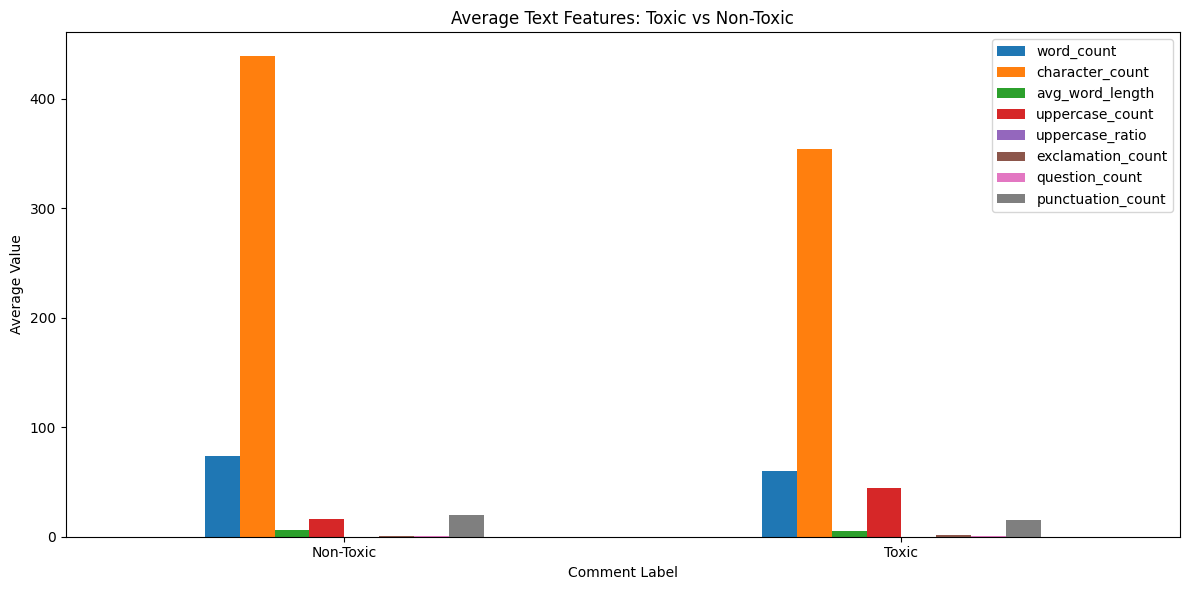

In [90]:
import matplotlib.pyplot as plt

feature_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Text Features: Toxic vs Non-Toxic")
plt.xlabel("Comment Label")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

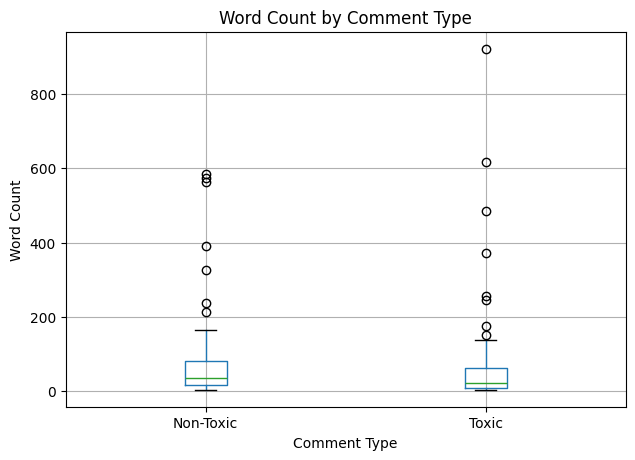

In [91]:
df.boxplot(
    column="word_count",
    by="manual_label",
    figsize=(7, 5)
)

plt.title("Word Count by Comment Type")
plt.suptitle("")
plt.xlabel("Comment Type")
plt.ylabel("Word Count")
plt.show()

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=1000
)

X_word_tfidf = word_tfidf.fit_transform(
    df["processed_text"]
)

print("TF-IDF matrix shape:", X_word_tfidf.shape)

TF-IDF matrix shape: (200, 1000)


In [93]:
feature_names = word_tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 1000

First 50 features:
['000' '04' '10' '15' '16' '17' '18' '19' '20' '2004' '2005' '2007'
 '2007 utc' '25' '28' '501' '56' '66' '80' 'able' 'absolutely' 'accept'
 'according' 'account' 'accurate' 'acknowledge' 'acknowledge uyghurs'
 'acknowledgment' 'act' 'action' 'actual' 'actually' 'ad' 'add' 'added'
 'adding' 'addition' 'address' 'admin' 'administrator' 'admins' 'age'
 'ago' 'agree' 'air' 'all' 'all powerful' 'all powerfulness' 'alleged'
 'allow']


In [94]:
tfidf_df = pd.DataFrame(
    X_word_tfidf.toarray(),
    columns=feature_names
)

print(tfidf_df.head())

   000   04   10   15   16   17   18   19   20  2004  ...  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...   

   wrongfully imprisoned  wrt  wwe  yashoda  yashoda devi  year  year old  \
0                    0.0  0.0  0.0      0.0           0.0   0.0       0.0   
1                    0.0  0.0  0.0      0.0           0.0   0.0       0.0   
2                    0.0  0.0  0.0      0.0           0.0   0.0       0.0   
3                    0.0  0.0  0.0      0.0           0.0   0.0       0.0   
4                    0.0  0.0  0.0      0.0           0.0   0.0       0.0   

   yes  zuck  zuckerberg  
0  0.0   0.0         0.0  
1  0.0   0.0         0.0  
2  0.0   0.0         0.0  
3  0.0   0.0         0.0  
4  0.0   0.0         0.0  

[5 rows

In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    max_features=1000
)

In [96]:
X_char_tfidf = char_tfidf.fit_transform(
    df["clean_text"]
)

print("Character TF-IDF shape:", X_char_tfidf.shape)

Character TF-IDF shape: (200, 1000)


In [97]:
char_features = char_tfidf.get_feature_names_out()

print("Number of character features:", len(char_features))

print("\nFirst 50 character features:")
print(char_features[:50])

Number of character features: 1000

First 50 character features:
[' ""' ' a ' ' ab' ' abo' ' abou' ' ac' ' ad' ' add' ' al' ' all' ' all '
 ' am' ' an' ' an ' ' and' ' and ' ' any' ' ar' ' are' ' are ' ' art'
 ' arti' ' as' ' as ' ' ass' ' at' ' at ' ' ba' ' be' ' be ' ' bec' ' bi'
 ' bl' ' bu' ' but' ' but ' ' by' ' by ' ' ca' ' can' ' can ' ' ch' ' co'
 ' com' ' con' ' cont' ' cu' ' de' ' del' ' di']


In [98]:
char_tfidf_df = pd.DataFrame(
    X_char_tfidf.toarray(),
    columns=char_features
)

print(char_tfidf_df.head())

         ""        a    ab   abo   abou   ac   ad   add        al   all  ...  \
0  0.051783  0.000000  0.0   0.0    0.0  0.0  0.0   0.0  0.000000   0.0  ...   
1  0.000000  0.000000  0.0   0.0    0.0  0.0  0.0   0.0  0.000000   0.0  ...   
2  0.000000  0.000000  0.0   0.0    0.0  0.0  0.0   0.0  0.000000   0.0  ...   
3  0.000000  0.000000  0.0   0.0    0.0  0.0  0.0   0.0  0.036189   0.0  ...   
4  0.000000  0.099853  0.0   0.0    0.0  0.0  0.0   0.0  0.000000   0.0  ...   

   y w  y wi       you      you      you a  you p  you,  you,   your  your   
0  0.0   0.0  0.026772  0.030989  0.049134    0.0   0.0    0.0   0.0    0.0  
1  0.0   0.0  0.000000  0.000000  0.000000    0.0   0.0    0.0   0.0    0.0  
2  0.0   0.0  0.000000  0.000000  0.000000    0.0   0.0    0.0   0.0    0.0  
3  0.0   0.0  0.023489  0.027189  0.000000    0.0   0.0    0.0   0.0    0.0  
4  0.0   0.0  0.000000  0.000000  0.000000    0.0   0.0    0.0   0.0    0.0  

[5 rows x 1000 columns]


In [99]:
print("Word-level TF-IDF:")
print(X_word_tfidf.shape)

print("\nCharacter-level TF-IDF:")
print(X_char_tfidf.shape)

Word-level TF-IDF:
(200, 1000)

Character-level TF-IDF:
(200, 1000)


In [100]:
from scipy.sparse import hstack

X_combined = hstack([
    X_word_tfidf,
    X_char_tfidf
])

print("Combined feature shape:", X_combined.shape)

Combined feature shape: (200, 2000)


In [101]:
from scipy.sparse import save_npz

save_npz(
    "word_tfidf_features.npz",
    X_word_tfidf
)

save_npz(
    "char_tfidf_features.npz",
    X_char_tfidf
)

save_npz(
    "combined_tfidf_features.npz",
    X_combined
)

print("TF-IDF features saved successfully.")

TF-IDF features saved successfully.


In [103]:
feature_columns = [
    "word_count",
    "character_count",
    "avg_word_length",
    "uppercase_count",
    "uppercase_ratio",
    "exclamation_count",
    "question_count",
    "punctuation_count"
]

feature_comparison = df.groupby("manual_label")[feature_columns].mean()

print(feature_comparison.round(2))

              word_count  character_count  avg_word_length  uppercase_count  \
manual_label                                                                  
Non-Toxic          73.75           438.87             5.87            16.61   
Toxic              60.48           354.14             5.63            44.09   

              uppercase_ratio  exclamation_count  question_count  \
manual_label                                                       
Non-Toxic                0.05               0.38            0.32   
Toxic                    0.09               1.81            0.49   

              punctuation_count  
manual_label                     
Non-Toxic                 19.66  
Toxic                     15.67  


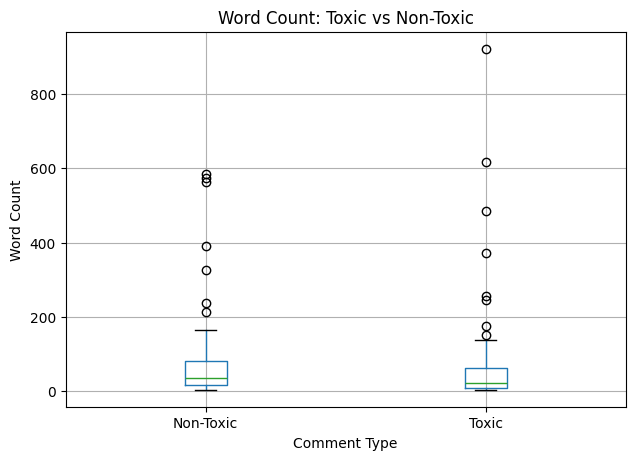

In [107]:
import matplotlib.pyplot as plt

df.boxplot(
    column="word_count",
    by="manual_label",
    figsize=(7, 5)
)

plt.title("Word Count: Toxic vs Non-Toxic")
plt.suptitle("")
plt.xlabel("Comment Type")
plt.ylabel("Word Count")
plt.show()

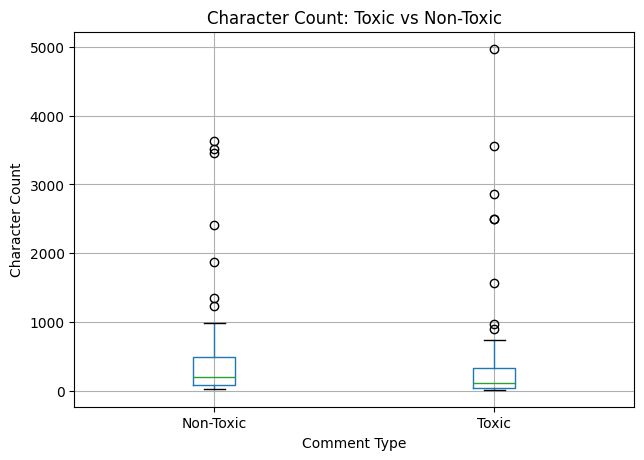

In [105]:
df.boxplot(
    column="character_count",
    by="manual_label",
    figsize=(7, 5)
)

plt.title("Character Count: Toxic vs Non-Toxic")
plt.suptitle("")
plt.xlabel("Comment Type")
plt.ylabel("Character Count")
plt.show()

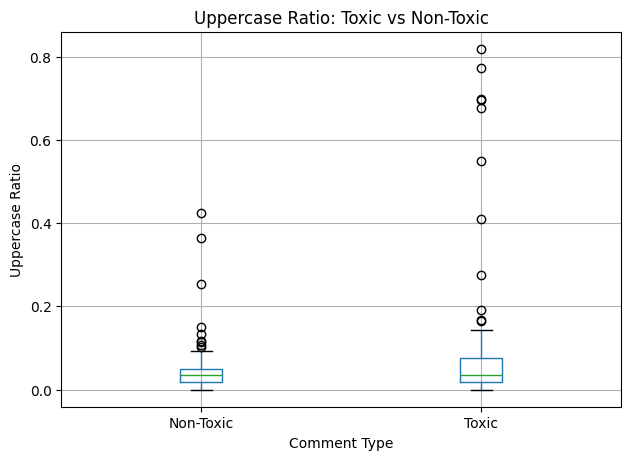

In [106]:
df.boxplot(
    column="uppercase_ratio",
    by="manual_label",
    figsize=(7, 5)
)

plt.title("Uppercase Ratio: Toxic vs Non-Toxic")
plt.suptitle("")
plt.xlabel("Comment Type")
plt.ylabel("Uppercase Ratio")
plt.show()

In [111]:
X_word_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3295 stored elements and shape (200, 1000)>

In [112]:
word_tfidf.get_feature_names_out()

array(['000', '04', '10', '15', '16', '17', '18', '19', '20', '2004',
       '2005', '2007', '2007 utc', '25', '28', '501', '56', '66', '80',
       'able', 'absolutely', 'accept', 'according', 'account', 'accurate',
       'acknowledge', 'acknowledge uyghurs', 'acknowledgment', 'act',
       'action', 'actual', 'actually', 'ad', 'add', 'added', 'adding',
       'addition', 'address', 'admin', 'administrator', 'admins', 'age',
       'ago', 'agree', 'air', 'all', 'all powerful', 'all powerfulness',
       'alleged', 'allow', 'allowed', 'already', 'also', 'alternative',
       'always', 'american', 'among', 'anal', 'anal oral', 'analysis',
       'another', 'anti', 'anyone', 'anything', 'anything even',
       'anywhere', 'apology', 'appeal', 'appealed', 'appear', 'appears',
       'appreciate', 'appropriate', 'arab', 'archive', 'argument',
       'around', 'article', 'article properly', 'article talk', 'as',
       'as dickface', 'ask', 'asks', 'assertion', 'assessment', 'asshole',
   

In [113]:

feature_names = word_tfidf.get_feature_names_out()

mean_tfidf = np.asarray(
    X_word_tfidf.mean(axis=0)
).flatten()

tfidf_ranking = pd.DataFrame({
    "feature": feature_names,
    "mean_tfidf": mean_tfidf
})

tfidf_ranking = tfidf_ranking.sort_values(
    "mean_tfidf",
    ascending=False
)

print(tfidf_ranking.head(20))

       feature  mean_tfidf
77     article    0.035330
659       page    0.029992
880       talk    0.028706
313       fuck    0.027218
964  wikipedia    0.024338
681     please    0.024322
649        one    0.022180
611       need    0.021192
518       like    0.021038
851       stop    0.020559
860     stupid    0.018236
905      think    0.017812
327        get    0.017561
897      thank    0.016799
883  talk page    0.013841
662     people    0.013829
517       life    0.013389
338         go    0.012914
243       edit    0.012755
771    section    0.012669


In [116]:
toxic_mask = (df["manual_label"].values == "Toxic")
non_toxic_mask = (df["manual_label"].values == "Non-Toxic")

print("Toxic comments:", toxic_mask.sum())
print("Non-Toxic comments:", non_toxic_mask.sum())

Toxic comments: 107
Non-Toxic comments: 93


In [117]:
toxic_tfidf = np.asarray(
    X_word_tfidf[toxic_mask].mean(axis=0)
).flatten()

toxic_features = pd.DataFrame({
    "feature": feature_names,
    "tfidf": toxic_tfidf
}).sort_values(
    "tfidf",
    ascending=False
)

print("Top TF-IDF features in Toxic comments:")
print(toxic_features.head(20))

Top TF-IDF features in Toxic comments:
       feature     tfidf
313       fuck  0.050874
860     stupid  0.033441
851       stop  0.030478
518       like  0.029572
964  wikipedia  0.024344
517       life  0.024145
77     article  0.023116
659       page  0.023086
288        fag  0.021849
662     people  0.021514
315    fucking  0.021413
406      idiot  0.020949
327        get  0.020266
321        gay  0.020205
253      edits  0.018555
338         go  0.018337
795       shit  0.018058
649        one  0.016904
86     asshole  0.016148
220       dick  0.015587


In [118]:
non_toxic_tfidf = np.asarray(
    X_word_tfidf[non_toxic_mask].mean(axis=0)
).flatten()

non_toxic_features = pd.DataFrame({
    "feature": feature_names,
    "tfidf": non_toxic_tfidf
}).sort_values(
    "tfidf",
    ascending=False
)

print("Top TF-IDF features in Non-Toxic comments:")
print(non_toxic_features.head(20))

Top TF-IDF features in Non-Toxic comments:
       feature     tfidf
77     article  0.049383
880       talk  0.047254
659       page  0.037939
681     please  0.036990
611       need  0.032519
649        one  0.028249
897      thank  0.024603
964  wikipedia  0.024330
243       edit  0.023688
883  talk page  0.022478
905      think  0.021803
981         wp  0.021401
932        utc  0.020158
898     thanks  0.019934
828     source  0.019150
413      image  0.018561
771    section  0.018283
716     reason  0.016972
217   deletion  0.016743
561        may  0.016591


In [119]:
comparison = pd.DataFrame({
    "feature": feature_names,
    "toxic_tfidf": toxic_tfidf,
    "non_toxic_tfidf": non_toxic_tfidf
})

comparison["difference"] = (
    comparison["toxic_tfidf"] -
    comparison["non_toxic_tfidf"]
)

comparison = comparison.sort_values(
    "difference",
    ascending=False
)

print("Features more associated with Toxic comments:")
print(comparison.head(20))

Features more associated with Toxic comments:
     feature  toxic_tfidf  non_toxic_tfidf  difference
313     fuck     0.050874         0.000000    0.050874
860   stupid     0.033441         0.000742    0.032700
517     life     0.024145         0.001014    0.023131
288      fag     0.021849         0.000000    0.021849
851     stop     0.030478         0.009147    0.021331
406    idiot     0.020949         0.000000    0.020949
321      gay     0.020205         0.000000    0.020205
315  fucking     0.021413         0.001790    0.019623
518     like     0.029572         0.011219    0.018353
795     shit     0.018058         0.000000    0.018058
662   people     0.021514         0.004988    0.016527
86   asshole     0.016148         0.000000    0.016148
289   faggot     0.014724         0.000000    0.014724
253    edits     0.018555         0.004137    0.014418
377     hell     0.013194         0.000000    0.013194
80        as     0.014043         0.001108    0.012935
789      sex     0.

In [120]:
print("Features more associated with Non-Toxic comments:")
print(
    comparison.sort_values(
        "difference",
        ascending=True
    ).head(20)
)

Features more associated with Non-Toxic comments:
       feature  toxic_tfidf  non_toxic_tfidf  difference
880       talk     0.012585         0.047254   -0.034670
77     article     0.023116         0.049383   -0.026268
681     please     0.013311         0.036990   -0.023679
981         wp     0.000000         0.021401   -0.021401
611       need     0.011347         0.032519   -0.021172
243       edit     0.003252         0.023688   -0.020436
932        utc     0.001896         0.020158   -0.018262
898     thanks     0.002375         0.019934   -0.017559
828     source     0.002115         0.019150   -0.017035
716     reason     0.000000         0.016972   -0.016972
217   deletion     0.000000         0.016743   -0.016743
413      image     0.001861         0.018561   -0.016699
883  talk page     0.006334         0.022478   -0.016144
188    content     0.000000         0.015824   -0.015824
561        may     0.000898         0.016591   -0.015693
826      sorry     0.000066         0.

In [121]:
correlation = df[feature_columns].corr()

print(correlation.round(2))

                   word_count  character_count  avg_word_length  \
word_count               1.00             0.99             0.10   
character_count          0.99             1.00             0.17   
avg_word_length          0.10             0.17             1.00   
uppercase_count          0.41             0.44             0.11   
uppercase_ratio          0.03             0.04             0.04   
exclamation_count        0.25             0.28             0.08   
question_count           0.26             0.29             0.25   
punctuation_count        0.87             0.91             0.27   

                   uppercase_count  uppercase_ratio  exclamation_count  \
word_count                    0.41             0.03               0.25   
character_count               0.44             0.04               0.28   
avg_word_length               0.11             0.04               0.08   
uppercase_count               1.00             0.50               0.91   
uppercase_ratio           

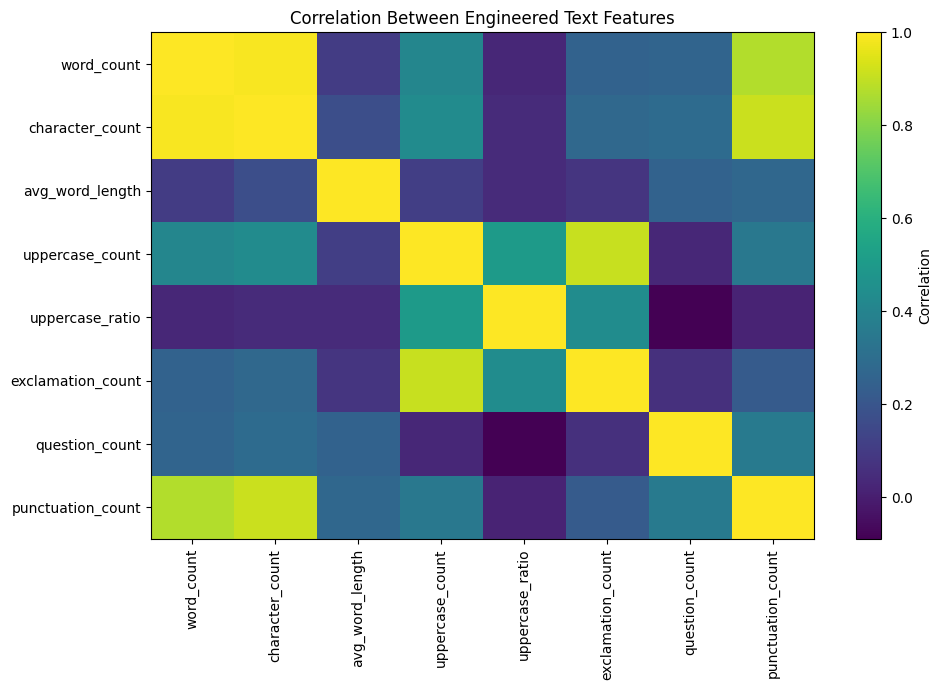

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Between Engineered Text Features")
plt.tight_layout()
plt.show()

In [123]:
output_columns = [
    "annotation_id",
    "comment_text",
    "manual_label",
    "category",
    "word_count",
    "character_count",
    "avg_word_length",
    "uppercase_count",
    "uppercase_ratio",
    "exclamation_count",
    "question_count",
    "punctuation_count"
]

df[output_columns].to_csv(
    "toxic_comment_engineered_features.csv",
    index=False
)

print("Feature dataset saved successfully!")

Feature dataset saved successfully!
